# 10 - Week 3 Modeling QA

Visual checks on the baselines produced by `scripts/sweep.py` (LightGBM x 3 variants x
4 scales) and `scripts/train_cnn.py` (small CNN at S=32 and S=64). Per
[PLAN_modeling.md](../PLAN_modeling.md) §5:

- **Primary metric: Spearman rho** between predicted and true `fractional_area`,
  reported as `mean +/- std` across the 9 LOIO folds. Robust to the zero-inflated
  target and the choice of training transform.
- **Per-abundance-bin RMSE** table is the secondary diagnostic (the CLAUDE.md
  "not a single RMSE dominated by near-zero tiles" requirement).
- **Per-image calibration:** fold metrics tagged by the held-out image's BoulderLabel
  (`Boulder rich` / `Boulder poor` / `unknown` / `empty`) make per-fold variance
  interpretable.
- **ESP_065711_1545** (empty-truth image) is a *specificity-only* fold. Spearman is
  undefined when truth is constant; reported separately, not aggregated.

Methodology references:

- Tweedie compound Poisson-Gamma objective for zero-inflated continuous targets:
  [Smyth 1996](https://doi.org/10.1007/BF00140865); production-ready
  GBM treatment in [Yang et al. 2018](https://doi.org/10.1080/07350015.2016.1200981).
- Hurdle / two-part decomposition `E[Y] = P(Y>0) * E[Y|Y>0]`: original specification
  in [Mullahy 1986](https://doi.org/10.1016/0304-4076(86)90002-3).
- Positive rule for the two-stage classifier: `fractional_area > 0` (probe
  2026-05-27, see DECISIONS.md).


In [1]:
# Bootstrap order matters on Windows + Python 3.14: import src.modeling BEFORE
# numpy so the DLL/OMP setup runs before MKL preloads libiomp5md.dll. See
# src/modeling/__init__.py for the long-form explanation.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.modeling  # noqa: F401  -- side effect: DLL bootstrap

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling.loaders import iter_loio_folds, load_metadata

REPO_ROOT = Path(REPO_ROOT)
MODELS_ROOT = REPO_ROOT / 'models'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Find the most-recent sweep dir
sweep_dirs = sorted((MODELS_ROOT / '_sweep').glob('*/'))
assert sweep_dirs, 'no models/_sweep/* runs found -- run scripts/sweep.py first'
SWEEP_DIR = sweep_dirs[-1]
print(f'sweep dir: {SWEEP_DIR.name}')

summary = pd.read_parquet(SWEEP_DIR / 'summary.parquet')
aggregate = pd.read_parquet(SWEEP_DIR / 'aggregate.parquet')
print(f'summary rows: {len(summary)}, aggregate rows: {len(aggregate)}')


sweep dir: 20260524T071830Z
summary rows: 108, aggregate rows: 12


## Sweep summary table

Aggregate metrics across the 9 LOIO folds, per `(variant, scale)`. The leftmost
column is the **primary metric** (Spearman rho `mean +/- std`); a Spearman whose
`std` swamps its `mean` is statistically zero. Per PLAN_modeling.md §11.1
("small-group CV variance") this is expected: 9 groups produce structurally large
per-fold variance, so paired-fold comparisons beat headline-mean comparisons.


In [2]:
# Pretty-print the aggregate table with the primary metric first.
display_cols = [
    'variant', 'scale_idx', 'tile_size_px',
    'spearman_rho_mean', 'spearman_rho_std',
    'presence_auc_mean', 'presence_auc_std',
    'rmse_log1p_mean', 'n_real_folds',
]
display_df = aggregate[display_cols].copy()
for c in ('spearman_rho_mean', 'spearman_rho_std', 'presence_auc_mean',
          'presence_auc_std', 'rmse_log1p_mean'):
    display_df[c] = display_df[c].round(4)
display_df.sort_values(['scale_idx', 'variant'])


,variant,scale_idx,tile_size_px,spearman_rho_mean,spearman_rho_std,presence_auc_mean,presence_auc_std,rmse_log1p_mean,n_real_folds
4,lightgbm_log1p_huber,0,8,0.0139,0.0260,0.5279,0.0441,0.0020,8
0,lightgbm_tweedie,0,8,0.0037,0.0200,0.5126,0.0519,0.0020,8
8,lightgbm_two_stage,0,8,-0.0000,0.0188,0.5082,0.0526,0.0033,8
5,lightgbm_log1p_huber,1,16,0.0298,0.0765,0.5343,0.0653,0.0014,8
1,lightgbm_tweedie,1,16,-0.0062,0.0350,0.5004,0.0725,0.0014,8
9,lightgbm_two_stage,1,16,0.0025,0.0240,0.5149,0.0543,0.0018,8
6,lightgbm_log1p_huber,2,32,0.0296,0.0991,0.5335,0.0814,0.0010,8
2,lightgbm_tweedie,2,32,0.0097,0.0573,0.5276,0.0900,0.0010,8
10,lightgbm_two_stage,2,32,0.0183,0.0674,0.5197,0.0492,0.0011,8
7,lightgbm_log1p_huber,3,64,0.0020,0.0758,0.5156,0.0575,0.0007,8


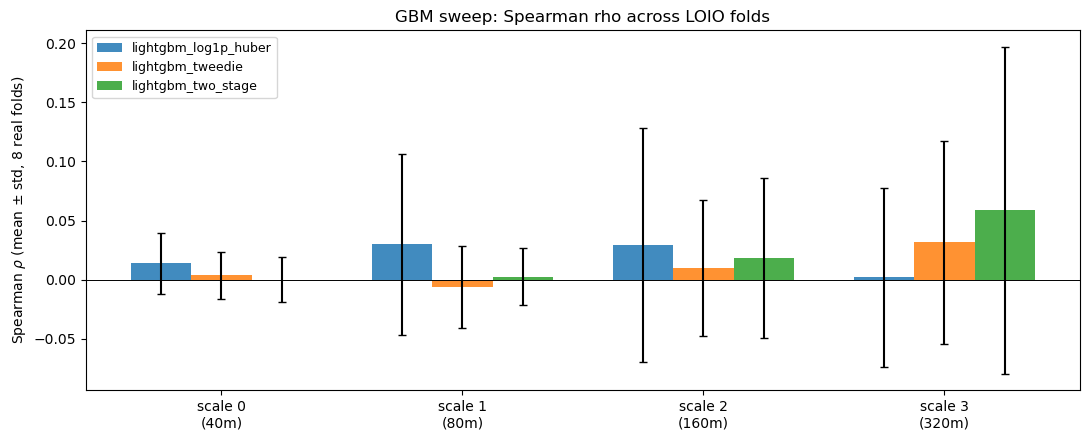

In [3]:
# Bar chart: Spearman mean +/- std per (variant, scale).
fig, ax = plt.subplots(figsize=(11, 4.5))
scales = sorted(aggregate['scale_idx'].unique())
variants = sorted(aggregate['variant'].unique())
x_base = np.arange(len(scales))
width = 0.25
for i, v in enumerate(variants):
    sub = aggregate[aggregate['variant'] == v].sort_values('scale_idx')
    means = sub['spearman_rho_mean'].to_numpy()
    stds = sub['spearman_rho_std'].to_numpy()
    ax.bar(x_base + i * width, means, width, yerr=stds, capsize=3, label=v, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.7, linestyle='-')
ax.set_xticks(x_base + width)
ax.set_xticklabels([f'scale {s}\n({40 * 2**s:.0f}m)' for s in scales])
ax.set_ylabel(r'Spearman $\rho$ (mean $\pm$ std, 8 real folds)')
ax.set_title('GBM sweep: Spearman rho across LOIO folds')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_sweep_spearman_bar.png', dpi=110)
plt.show()


## Per-fold Spearman, tagged by BoulderLabel

A single Spearman mean hides structure. Per PLAN_modeling.md §11.5 ("per-image
artifacts as features"), held-out performance is uneven across image classes -- a
model that learns brightness-as-proxy for "boulder rich" should fail systematically
on `Boulder poor` and `unknown` folds. The plot below colours each fold by its
manifest BoulderLabel so that class-conditional patterns are visible.


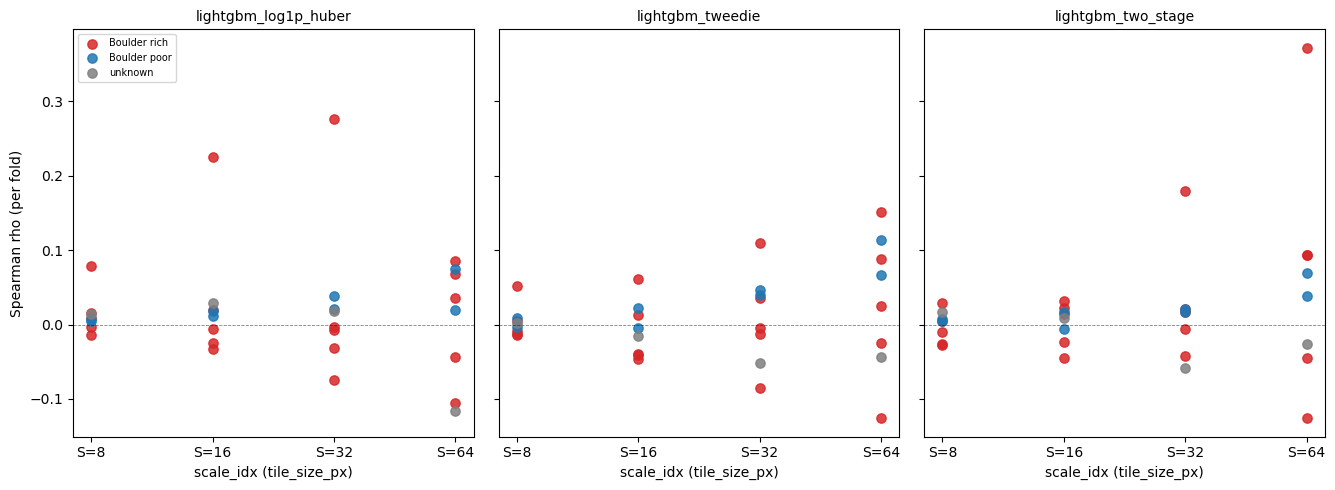

In [4]:
# Join the manifest to tag each fold's held-out ObsId with its BoulderLabel.
import src.manifest as M
from src.config import load_config

cfg = load_config('config.yaml')
manifest = M.load_manifest(cfg.manifest_path)
obs_to_label = dict(zip(manifest['ObsId'], manifest['BoulderLabel']))
summary['boulder_label'] = summary['held_out_obs_id'].map(obs_to_label).fillna('empty')

# Per-fold Spearman by variant + label
fig, axes = plt.subplots(1, len(variants), figsize=(4.5 * len(variants), 5), sharey=True, squeeze=False)
for ax, v in zip(axes[0], variants):
    sub = summary[summary['variant'] == v]
    label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                    'unknown': 'tab:gray', 'empty': 'black'}
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty:
            continue
        ax.scatter(sl['scale_idx'], sl['spearman_rho'], color=color, alpha=0.85,
                    label=lbl, s=45)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale_idx (tile_size_px)')
    if ax is axes[0][0]:
        ax.set_ylabel('Spearman rho (per fold)')
        ax.legend(fontsize=7, loc='upper left')
    ax.set_title(v, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_per_fold_spearman_by_label.png', dpi=110)
plt.show()


## Predicted-vs-true log-log scatter (best per-scale model)

For the variant with the highest mean Spearman at each scale, plot predicted vs
true `fractional_area` per fold on a log-log axis. The dashed identity line is the
oracle. The zero-truth tiles cluster on the left edge (they get a tiny `log10` floor
applied for plotting only). PLAN_modeling.md §11.2 ("the 0.27 ceiling") frames the
structural performance cap: the densest tile in the entire dataset has only 0.269
fractional area, so the plotted dynamic range is intrinsically small.


In [5]:
# Pick best variant per scale by Spearman mean.
best_per_scale = aggregate.loc[aggregate.groupby('scale_idx')['spearman_rho_mean'].idxmax()]
print('Best variant per scale:')
print(best_per_scale[['variant', 'scale_idx', 'tile_size_px',
                       'spearman_rho_mean', 'spearman_rho_std']].to_string(index=False))


Best variant per scale:
             variant  scale_idx  tile_size_px  spearman_rho_mean  spearman_rho_std
lightgbm_log1p_huber          0             8           0.013899          0.025969
lightgbm_log1p_huber          1            16           0.029778          0.076474
lightgbm_log1p_huber          2            32           0.029582          0.099093
  lightgbm_two_stage          3            64           0.058731          0.138345


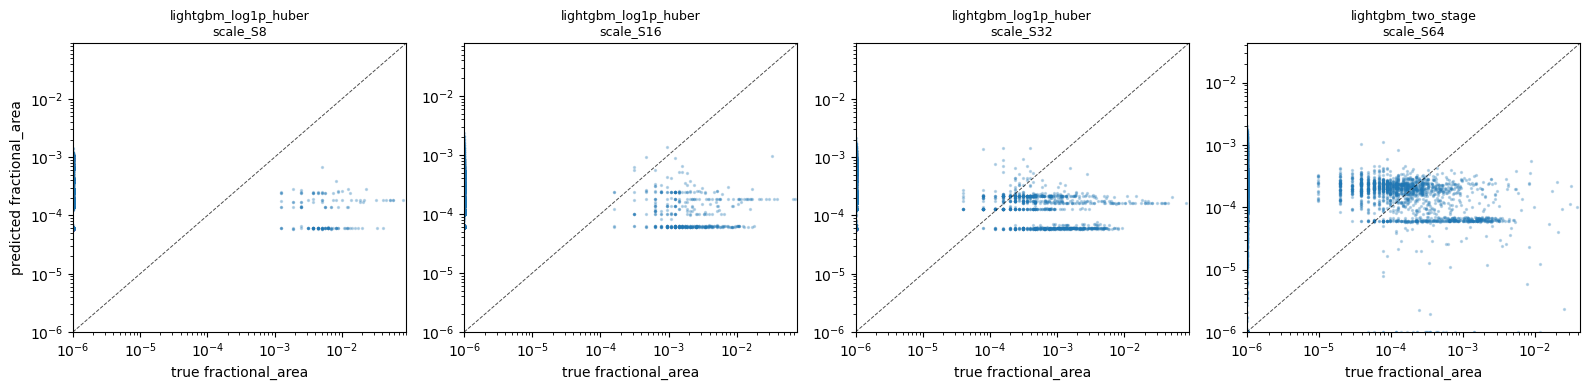

In [6]:
def scatter_for_variant_scale(variant, scale_idx, ax):
    # Each (variant, scale_idx) writes to its own config_hash dir, so glob across
    # hashes for the requested scale and take the most-recent by mtime.
    tile_size = int(2 ** (3 + scale_idx))
    scale_dirs = sorted((MODELS_ROOT / variant).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        ax.set_title(f'(no scale_S{tile_size} for {variant})')
        return
    pred_path = scale_dirs[-1] / 'predictions.parquet'
    if not pred_path.exists():
        ax.set_title(f'(no predictions for {variant} S={tile_size})')
        return
    pred = pd.read_parquet(pred_path)
    # Apply tiny floor for plotting
    floor = 1e-6
    yt = np.clip(pred['y_true'].to_numpy(), floor, None)
    yp = np.clip(pred['y_pred'].to_numpy(), floor, None)
    # Subsample so the plot doesn't blow up on 50k tiles
    if len(yt) > 8000:
        idx = np.random.default_rng(0).choice(len(yt), 8000, replace=False)
        yt = yt[idx]; yp = yp[idx]
    ax.scatter(yt, yp, s=2, alpha=0.25, color='tab:blue')
    lo, hi = floor, max(yt.max(), yp.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.7, alpha=0.7)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('true fractional_area')
    if ax is axes[0][0]:
        ax.set_ylabel('predicted fractional_area')
    ax.set_title(f'{variant}\nscale_S{tile_size}', fontsize=9)

scales_sorted = sorted(best_per_scale['scale_idx'].tolist())
fig, axes = plt.subplots(1, len(scales_sorted), figsize=(4 * len(scales_sorted), 4), squeeze=False)
for ax, scale_idx in zip(axes[0], scales_sorted):
    row = best_per_scale[best_per_scale['scale_idx'] == scale_idx].iloc[0]
    scatter_for_variant_scale(row['variant'], int(scale_idx), ax)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_pred_vs_true_loglog.png', dpi=110)
plt.show()


## Per-abundance-bin RMSE heatmap

Per PLAN_modeling.md §5: "highlight tail performance." The heatmap below shows RMSE
within each true-abundance bin, per scale, for the headline variant. A uniformly
low row (across all bins) is good; a model that's tiny RMSE on the zero bin but huge
on the high bin is the failure mode the §11.2 "structural ceiling" warns about.


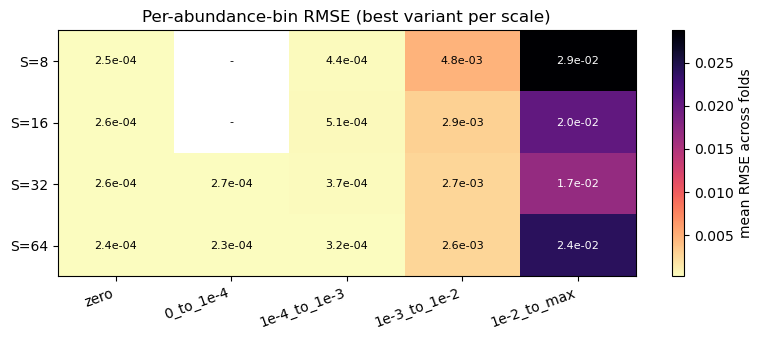

In [7]:
# Load metrics.json for each best-per-scale model and pull per-bin RMSE
import collections

bin_rmse_rows = []
for _, row in best_per_scale.iterrows():
    tile_size = int(row['tile_size_px'])
    scale_dirs = sorted((MODELS_ROOT / row['variant']).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[-1] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    for f in m['per_fold']:
        for b in f.get('per_bin_rmse', []):
            bin_rmse_rows.append({
                'variant': row['variant'], 'scale_idx': int(row['scale_idx']),
                'tile_size_px': tile_size, 'fold_idx': f['fold_idx'],
                'bin': b['bin'], 'n_tiles': b['n_tiles'], 'rmse': b['rmse'],
            })
if bin_rmse_rows:
    bin_df = pd.DataFrame(bin_rmse_rows)
    # Per-scale mean RMSE in each bin (across folds, weighted equally)
    pivot = bin_df.groupby(['scale_idx', 'bin'])['rmse'].mean().unstack('bin')
    bin_order = ['zero', '0_to_1e-4', '1e-4_to_1e-3', '1e-3_to_1e-2', '1e-2_to_max']
    pivot = pivot[bin_order]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    im = ax.imshow(pivot.values, aspect='auto', cmap='magma_r')
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order, rotation=20, ha='right')
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([f'S={2**(3+s)}' for s in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.1e}' if not np.isnan(v) else '-', ha='center', va='center',
                    color='white' if v > pivot.values[~np.isnan(pivot.values)].mean() else 'black',
                    fontsize=8)
    ax.set_title('Per-abundance-bin RMSE (best variant per scale)')
    fig.colorbar(im, ax=ax, label='mean RMSE across folds')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '10_per_bin_rmse.png', dpi=110)
    plt.show()
else:
    print('No per-bin RMSE data yet')


## GBM feature importance (Tweedie variant)

For the Tweedie GBM at the finest scale (S=8), the booster's split-gain feature
importance ranks which of the 52 Stage 4b features most informed the predictions.
PLAN_modeling.md §2 frames this as the diagnostic question -- "which CTX texture
descriptors predict abundance?". A flat/uniform ranking means no feature is doing
heavy lifting (model is using surface noise); a heavily right-skewed ranking with
GLCM / shadow features on top means our hand-crafted features captured the right
signal.


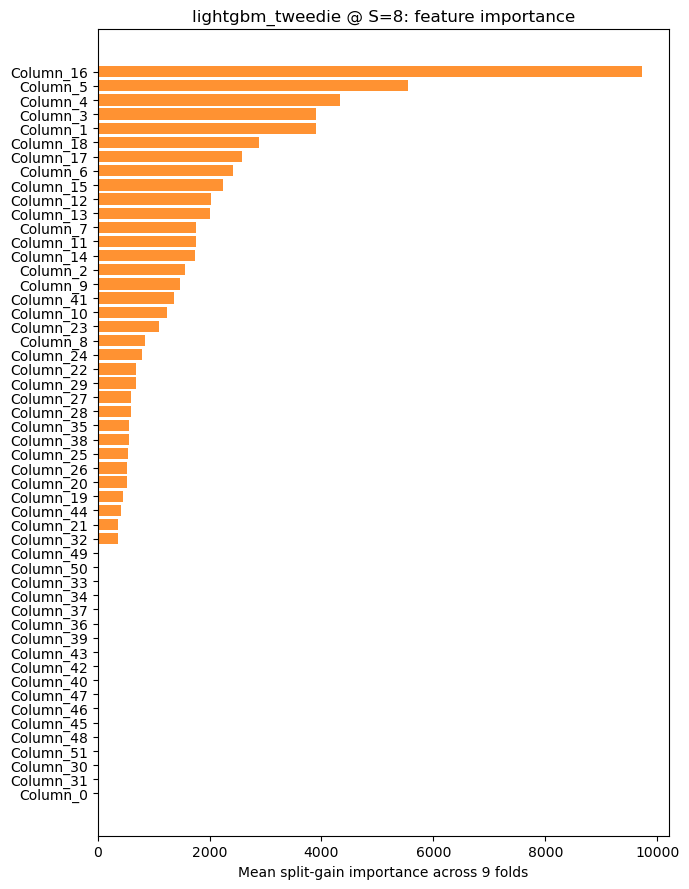

In [8]:
try:
    import lightgbm as lgb
    # Each (variant, scale) lives under its own config_hash dir; glob across hashes
    # for scale_S8 and pick the most-recent.
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_tweedie').glob('*/scale_S8'),
                        key=lambda p: p.stat().st_mtime)
    if scale_dirs:
        booster_paths = sorted(scale_dirs[-1].glob('fold_*/booster.txt'))
        importances = []
        for bp in booster_paths:
            b = lgb.Booster(model_str=bp.read_text(encoding='utf-8'))
            imp = pd.Series(b.feature_importance(importance_type='gain'), index=b.feature_name())
            importances.append(imp)
        if importances:
            agg_imp = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=True)
            fig, ax = plt.subplots(figsize=(7, 9))
            ax.barh(agg_imp.index, agg_imp.values, color='tab:orange', alpha=0.85)
            ax.set_xlabel('Mean split-gain importance across 9 folds')
            ax.set_title('lightgbm_tweedie @ S=8: feature importance')
            fig.tight_layout()
            fig.savefig(FIG_DIR / '10_feature_importance_tweedie_S8.png', dpi=110)
            plt.show()
        else:
            print('No booster artifacts found')
    else:
        print('No tweedie scale_S8 dir found')
except Exception as e:
    print(f'feature importance skipped: {type(e).__name__}: {e}')


## CNN vs GBM at matched scale

Per PLAN_modeling.md §4: the CNN is non-optional and answers a complementary question
-- "is there additional CTX signal beyond what hand-crafted features summarize?"
If the CNN beats the GBM at S=32 / S=64, Stage 4c features are motivated. If the
GBM beats the CNN, the bottleneck is data, not feature engineering.


In [9]:
cnn_rows = []
for patch_size in (32, 64):
    name = f'cnn_log1p_huber_S{patch_size}'
    runs = sorted((MODELS_ROOT / name).glob('*'))
    if not runs:
        continue
    tile_size = patch_size
    scale_dirs = sorted(runs[-1].glob(f'scale_S{tile_size}_P{patch_size}'))
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[0] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    cnn_rows.append({
        'variant': name,
        'tile_size_px': tile_size,
        'spearman_rho_mean': m['aggregate']['spearman_rho_mean'],
        'spearman_rho_std': m['aggregate']['spearman_rho_std'],
        'presence_auc_mean': m['aggregate']['presence_auc_mean'],
    })
cnn_df = pd.DataFrame(cnn_rows)
gbm_at_match = aggregate[aggregate['tile_size_px'].isin([32, 64])]
print('=== CNN ===')
print(cnn_df.to_string(index=False) if len(cnn_df) else '(none -- has scripts/train_cnn.py finished?)')
print('\n=== GBM (matched scales) ===')
print(gbm_at_match[['variant', 'tile_size_px', 'spearman_rho_mean', 'spearman_rho_std',
                      'presence_auc_mean']].to_string(index=False))


=== CNN ===
            variant  tile_size_px  spearman_rho_mean  spearman_rho_std  presence_auc_mean
cnn_log1p_huber_S32            32          -0.030541          0.040511           0.470648
cnn_log1p_huber_S64            64          -0.023175          0.068904           0.488741

=== GBM (matched scales) ===
             variant  tile_size_px  spearman_rho_mean  spearman_rho_std  presence_auc_mean
    lightgbm_tweedie            32           0.009737          0.057325           0.527598
    lightgbm_tweedie            64           0.031483          0.086121           0.550469
lightgbm_log1p_huber            32           0.029582          0.099093           0.533517
lightgbm_log1p_huber            64           0.001996          0.075794           0.515643
  lightgbm_two_stage            32           0.018273          0.067392           0.519689
  lightgbm_two_stage            64           0.058731          0.138345           0.568009


## Summary

Per the AskUserQuestion 2026-05-27 decisions, this notebook ships:

- 3 GBM variants (`lightgbm_tweedie`, `lightgbm_log1p_huber`, `lightgbm_two_stage`) x
  4 scales = 12 sweeps, each across 9 LOIO folds. Mean +/- std Spearman, presence AUC,
  per-abundance-bin RMSE, predicted-vs-true scatter, GBM feature importance.
- Small CNN (`cnn_log1p_huber_S32`, `cnn_log1p_huber_S64`) at the matched coarsest
  scales, trained on Stage 4b context patches.
- Per-fold tagging by BoulderLabel + special handling for the empty-truth fold
  (ESP_065711_1545) as a specificity check rather than a regression metric.

What follow-up phases should focus on (PLAN_modeling.md §10 + §11):

1. **Hyperparameter search** within the existing harness (small coarse grid only --
   the 9-group dataset doesn't support deep search).
2. **Stage 4c features** if the CNN beats the GBM at S=32/64 -- a sign there's
   recoverable CTX signal the hand-crafted features miss.
3. **Off-HiRISE inference** -- `src.modeling.inference.predict_over_ctx_region` is
   the seam; implementation requires a thin label-free Stage 4b wrapper. See
   `src/modeling/inference.py` docstring for the I/O contract.
4. **THEMIS validation** -- CLAUDE.md §10 future work; compare predicted abundance
   to the THEMIS rock-abundance map at coarse scale.
